In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import numpy as np

### 1. Data Loading

We will use the Fashion-MNIST dataset for this task. It consists of 60,000 training images and 10,000 test images of Zalando's fashion articles, each in 28x28 grayscale images, associated with a label from 10 classes.

In [3]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to be between -1 and 1
])

# Download and load the Fashion-MNIST training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load the Fashion-MNIST test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}") # Should be [1, 28, 28]

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]

Number of training samples: 60000
Number of test samples: 10000
Image shape: torch.Size([1, 28, 28])


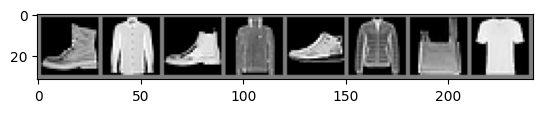

Ankle Boot Sandal Ankle Boot Dress Sneaker Dress Bag   T-shirt/top


In [4]:
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))

# Print labels (class names)
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Shirt',
           'Dress', 'Coat', 'Sandal', 'Sneaker', 'Bag', 'Ankle Boot')
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

### 2. Define the Fully Connected Neural Network (FCNN)

In [5]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input layer: 28*28 (flattened image) to 128 (hidden units)
        self.fc1 = nn.Linear(28*28, 128)
        # Output layer: 128 (hidden units) to 10 (number of classes)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Flatten the input image (batch_size, 1, 28, 28) to (batch_size, 784)
        x = x.view(x.size(0), -1)
        # Apply first fully connected layer
        x = self.fc1(x)
        # Apply ReLU activation function (commonly used after hidden layers)
        x = torch.relu(x)
        # Apply second fully connected layer (output layer)
        x = self.fc2(x)
        return x

# Instantiate the model
model = FCNN()
print(model)

FCNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 3. Training the FCNN

Epoch [1/10], Loss: 0.7976
Epoch [2/10], Loss: 0.5215
Epoch [3/10], Loss: 0.4738
Epoch [4/10], Loss: 0.4464
Epoch [5/10], Loss: 0.4273
Epoch [6/10], Loss: 0.4123
Epoch [7/10], Loss: 0.4007
Epoch [8/10], Loss: 0.3906
Epoch [9/10], Loss: 0.3811
Epoch [10/10], Loss: 0.3735
Finished Training


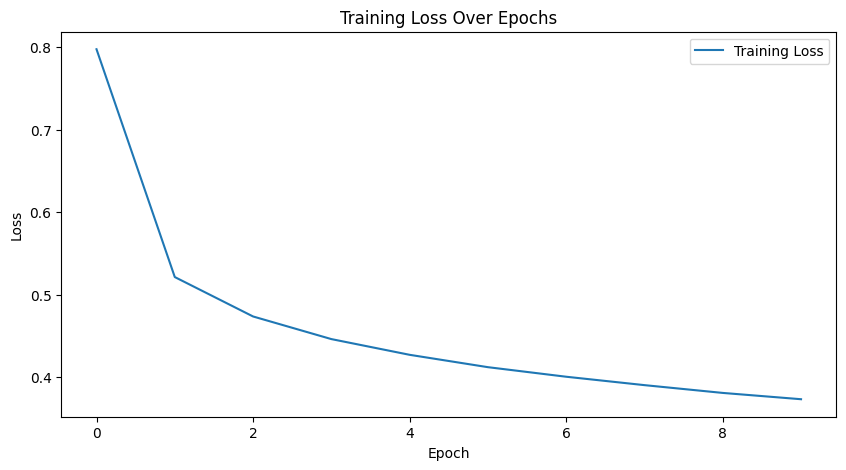

In [6]:
# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
num_epochs = 10
training_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

print('Finished Training')

# Visualize training loss
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

### 4. Evaluate the Model

In [7]:
# Evaluate the model on the test data
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient calculation during evaluation
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the FCNN on the 10000 test images: {accuracy:.2f}%')

Accuracy of the FCNN on the 10000 test images: 85.55%
